# Time-dependent temperature in a dissipative quantum harmonic oscillator
###   —— —— —— Computational project for PHYS-E0412 Computational physics —— —— ——

### Author: Junzhe Chen, 101745866

<a id="table"></a>
## Table of Contents

1. [Introduction]()
2. [Theory](#theory)
   1. [Equation of motion](#dynamics)
   2. [Time-dependent temperature](#dynamics)
   3. [Work and heat](#work)
   4. [Equation of motion](#Gaussian)
3. [Numerical solver](#solver)
   1. [RK4 solver](#Rk4)
   2. [System prameter and frequency functions](#parameter)
   3. [Helper functions for calculation and visualization](#helper)
4. [Result and analysis](#results)
   1. [Case A: Damping](#damping)
   2. [Case B: Step-like modulation](#step)
   3. [Case C: Sine modulation](#sine)
   
5. [Summary](#summary)

[Reference](#ref)

## 1. Introduction
The control over the temperature of nanoscale quantum systems is pivotal to many modern research fields,  such as developing various of thermal devices and investigations of fundamental concepts of quantum thermodynamics [[1]](#ref). The temperature of a quantum system in equilibrium state with its environment,  is defined on the thermal state which maximize the von Neumann entropy [[2]](#ref). 

While for non-equilibrium state, we can try to find effective temperature which is defined in the same form of Gibbs thermal state [[3]](#ref). The control of effective temperature is an interesting toy model in quantum thermodynamics giving some insights for fundamentals of this subject. To solve such system, the usual Lindblad master equation solver is slow due to exponentially increasing time cost. For Gaussian states, a simple ODE equivalent to master equation can be derived basd on open quantum theory [[1]](#ref). We will verify the equivalance in some typical cases. Furthermore, we would like to explore the reaction of a quantum system when external drive applied, especially the profile of heat output. The specific dynamics of frequency controlling quantum harmonic oscillator has not been discussed a lot yet, so would be interesting to explore. 

<a id="theory"></a>
## 2. Theory

<a id="dynamics"></a>
### Equation of motion
We examine single harminic oscillator, and the Hamiltonian is:
$$
H = \hbar\omega_0\left(a^{\dagger}a+\frac{1}{2}\right)
$$

When in contact with a thermal bath, the quantum dynamics of such system is described by the quantum optical master equation [[2]](#ref): 

$$
\begin{equation}
\frac{d\rho}{dt}=-i[H,\rho]+\gamma({n}_{T_{e}}+1)\mathcal{L}[a^{\dagger}]\rho+\gamma{n}_{T_e}\mathcal{L}[a]
\end{equation}
$$

where $\gamma$ is the damping rate at equilibrium, and $n_{T_e}$

$$
{n}_{T_e}=\frac{1}{e^{\hbar\omega_0/kT_e} -1}
$$

is the average photon number related to transition frequency $\omega_0$ and environment temperature $T_{e}$ by Bose-Einstein distribution. This equation form implies that the environment is in thermal state $\rho_{B}$. This equation can be easily solve using QuTip toolbox. 

To solve equilibrium quantum dynamics, the system is initialized as a thermal state, which is assigned with a temperature $\mathcal{T}(0)=T_0$ measured based on bath temperature $T_e$: 

$$
\rho_\mathcal{T_0}=\frac{ e^{-\beta H_{s}} }{ Tr(e^{-\beta H_{s}}) }
$$

where $\beta=1/kT_s$. We expect that for $T_s\neq T_e$, the system will gradually thermalize to bath temperature.  

### Time-dependent temperature
The above equation is applicable to systems with a fixed frequency. However, for systems with time-dependent frequency, assuming a white noise spectrum—wherein the coupling strength is uniform across all frequencies—the damping rate $\gamma$ remains constant and the equation of motion retains the same form. However, the photon number of Bose-Einstein distribution will become time-dependent.

This is achieved by replacing the constant $\omega_0$ with a time-dependent function, $\omega(t)=\omega_0+\delta \omega(t)$. The $\delta\omega(t)$ represents a time-dependent small perturbation of the frequency.

The thermal state $\rho_\mathcal{T(t)}$ contains bosonic particle numbers
$$
{n}_{\mathcal{T}}(t)=\frac{1}{e^{\hbar\omega(t)/k\mathcal{T}(t)} -1}
$$


We can define effective temperature $\mathcal{T}$ of system, which is related to the average photon number: 

$$
{n}_{\mathcal{T}}(t)=\frac{1}{e^{\hbar\omega(t)/k\mathcal{T}(t)} -1} \quad\Rightarrow\quad \mathcal{T}(t)=\frac{\hbar\omega(t)}{k}\left[\log\left(1+\frac{1}{\bar{n}_{\mathcal{T}}(t)}\right)\right]^{-1}
$$

<a id="work"></a>
### Work and Heat
In the context of thermodynamic quantities, which of the most importance and starting point, are work done on system and heat flow into thermal bath. The first law of thermodynamics states that internal change is equal to summations of these two quantities:  

$$
\Delta U = \delta W + \delta Q
$$

In quantum system, the internal energy is defined as [[4]](#ref):

$$
U = \langle U \rangle = \mathrm{Tr}(\rho H)
$$

The energy difference between two time:

$$
\begin{aligned}
\int \frac{dU}{dt}dt=\Delta U 
&=  \mathrm{Tr}(H(t)\rho(t))-\mathrm{Tr}(H(0)\rho(0))\\
&= \int d\tau \left\{\mathrm{Tr}(\dot{H}(\tau)\rho(\tau))+\mathrm{Tr}(H(\tau)\dot{\rho}(\tau))  \right\}
\end{aligned}
$$
where $\delta W$ is the total work done by externel drive, and $\delta Q$ is the total heat dissipated into environment:  

$$
\qquad 
\delta W = \int_{0}^{t} d\tau\space \mathrm{Tr}(\dot{H}(\tau)\rho(\tau)), \qquad 
\delta Q = \int_0^{t}d\tau \space \mathrm{Tr}(H(\tau)\dot{\rho}(\tau)) 
$$

The integrand of $\delta W$ and $\delta Q$ is defined as power and heat current, respectively. Positive heat current means absorbing heat energy from the bath, and vice versa. 

For numerical solutions, the integral of function $g(t)$ is approximated as Riemann sums: 

$$
\int g(t) dt \Rightarrow \sum_i g(t_i) \Delta t
$$

In our case, the Hamiltonian is time-dependent by frequency modulation:

$$
H = \hbar \omega(t)\left(n+\frac{1}{2}\right)
$$

Internel energy can be written as: 

$$
U(t) = \hbar \omega(t) \left(\langle n(t) \rangle +\frac{1}{2}\right)
$$

Taking the derivative, we seperate it as power of external drive $P$ and heat current into environment, $\mathcal{J}$:

$$
\frac{dU}{dt} = \hbar \dot{\omega}(t) \left(\langle n(t) \rangle +\frac{1}{2}\right) + \hbar \omega(t) \frac{d}{dt}\langle {n}(t) \rangle 
$$

These two quantities are of more interest than total work and heat in many cases.

<a id="Gaussian"></a>
### Equation of motion

The quantum optical master equation can be much simplified by phase space methods as introduced in [[3]](#ref). At last, a differential equaiton about photon number on system is derived: 

$$
\frac d{dt}n_T(\omega)=\gamma[n_{T_e}(\omega)-n_{\mathcal{T}}(\omega)]
$$

where $n_{\mathcal{T}}(\omega)$ and $n_{T_e}(\omega)$ are Bose-Einstein distribution for system and bath as introduced before. However, they become time-depedent now since the frequency now is time-dependent. 

Surprisingly, the master equation is transformed to a first-order ODE, which can be easily solved by numerical solver. Also think about the expression of power $P$ and heat current $\mathcal{J}$, we find that both of them are only dependent of $\langle n(t)\rangle$, $\omega(t)$, and their derivatives. This means this first order ODE give the enough information we need to simulate quantum thermodynamics in the context of single harmonic oscillator. 

<a id="solver"></a>

<a id="solver"></a>
## 3. Numerical Solver

<a id="RK4"></a>
### RK4 solver

To numerically solve a ODE, the RK4 method is typically the first choice to try becuase it balances well between accuracy and computational cost makes it very efficient. Other method certainly works as well. 

[(Back to top)](#table)

In [1]:
import numpy as np
from scipy.constants import hbar, k
import matplotlib.pyplot as plt
import time

In [2]:
def Rk4_step(n_T, t, dt, args):
    ''' Stepper of the RK4 integration method.'''
    k1 = dt * dN_dt(n_T, t, args)
    k2 = dt * dN_dt(n_T + 0.5 * k1, t + 0.5 * dt, args)
    k3 = dt * dN_dt(n_T + 0.5 * k2, t + 0.5 * dt, args)
    k4 = dt * dN_dt(n_T + k3, t + dt, args)
    return n_T + (k1 + 2 * k2 + 2 * k3 + k4) / 6

def solve_Rk4(n_T_initial, args, t_i, t_f, dt):
    '''
    Solve the differential equation using the RK4 method from t_initial to t_final with time step dt.

    Parameters:
    T_i (float): Initial value of the dependent variable.
    Tt (float): System temperature, assumed constant for this implementation.
    t_i (float): Initial time of the integration.
    t_f (float): Final time of the integration.
    dt (float): Time step size for the RK4 method.

    Returns:
    tuple: Two lists containing the times and the values of the dependent variable at those times.
    '''
    times = np.arange(t_i, t_f, dt)
    values = [n_T_initial]
    n_T = n_T_initial

    for t in times[:-1]:
        n_T = Rk4_step(n_T, t, dt, args)
        values.append(n_T)

    return times, np.array(values)

<a id="parameter"></a>
### System parameters and frequency control
Here we are interested in low tempreature case where the quantum effect dominant. The temperature of heat bath is picked at 100mK and of system is at 20mK, which are realistic choices for many low-temperature set-up. The frequency and time unit is chosen to be in GHz and ns, which are in balance. 

In [3]:
def step_function(t, T, A, B):
    """Returns the value of a periodic step function with period T, minimum A, and maximum B at x """
    return (np.floor(t / T) % 2) * (B - A) + A  # Alternates between A and B every T units

# Define the 
def omega_t(t, args):
    '''Frequency modulation of system, this function style compatible with QuTip'''
    shape = args['shape']
    if shape == None:
        raise ValueError('Incorrect pulse name')
    if shape == 'constant':
        pulse = 2*np.pi*w0
    if shape == 'sine':
        A = args['A']
        nu = args['nu']
        pulse = 2*np.pi*( w0 + A * np.sin(2*np.pi*nu * t) )
    if shape == 'step': 
        T = args['T']
        A = args['A']
        B = args['B']
        pulse = 2*np.pi*step_function(t, T, A, B)
    return pulse

def n_w(w, T):
    """Calculate time-dependent system thermal photon number linked to frequency and temperature"""
    return 1 / (np.exp((hbar*w*1e9)/(k*T)) - 1)        # w here without 2pi

def n_th(t, args):
    """Calculate Bose-Einstein distribution of environment thermal photon number linked to frequency"""
    omega = omega_t(t, args)
    return n_w(omega, Te)

def dN_dt(n_T, t, args):
    """The RHS of ODE"""
    return gamma * (n_th(t, args) - n_T)

# System parameters
Te = 0.1              # Temperature of the environment, Kelvin
T0 = 0.02             # Initial temperature of the system, K
gamma = 0.05          # Dissipation rate, assumed constant, GHz
w0 = 1                # System frequency, GHz
nu = 0.05             # Modulation frequency of sine wave, GHz
nth0 = n_w(2*np.pi*w0, T0) # Initial photon number

args_constant = {'shape':'constant'}
args_step = {'shape': 'step', 'T': 20, 'A': w0, 'B':2*w0}
args_sine = {'shape': 'sine', 'A': w0/4, 'nu':nu}       # Small perturbative case

<a id="helper"></a>
###  Helper functions for calculation and visualization
To avoid tedious calling matplotlib functions again and again, we design some customized functions for plotting results. 

In [4]:
def calculate_power_and_heat_current(times, omega_t, avg_n, args):
    """
    Calculate the instantaneous power and heat current at each time step.

    Parameters:
    hbar : float
        The reduced Planck constant.
    times : array-like
        The discrete time points at which the calculations are performed.
    omega_t : function
        A function that returns the frequency omega(t) at a given time with additional arguments.
    avg_n : array-like
        The average photon number at each time step.
    args : dict
        Additional arguments required for the omega_t function.

    Returns:
    power : array-like
        The power at each time step.
    heat_current : array-like
        The heat current at each time step.
    """
    hbar = 1
    # Initialize arrays to store power and heat current values
    power = np.zeros_like(times)
    heat_current = np.zeros_like(times)

    # Calculate power and heat current using central differences for the average photon number
    for i in range(1, len(times) - 1):
        dt = times[i+1] - times[i-1]
        # Compute the derivatives of the frequency and the average photon number
        dot_omega = (omega_t(times[i+1], args) - omega_t(times[i-1], args)) / dt
        d_avg_n_dt = (avg_n[i+1] - avg_n[i-1]) / dt
        
        # Calculate the instantaneous frequency
        omega = omega_t(times[i], args)
        
        # Calculate the power (rate of work done) and heat current
        power[i] = hbar * dot_omega * (avg_n[i] + 0.5)
        heat_current[i] = hbar * omega * d_avg_n_dt

    # For the first and last points, use forward/backward finite difference
    power[0] = hbar * (omega_t(times[1], args) - omega_t(times[0], args)) / (times[1] - times[0]) * (avg_n[0] + 0.5)
    heat_current[0] = hbar * omega_t(times[0], args) * (avg_n[1] - avg_n[0]) / (times[1] - times[0])
    power[-1] = hbar * (omega_t(times[-1], args) - omega_t(times[-2], args)) / (times[-1] - times[-2]) * (avg_n[-1] + 0.5)
    heat_current[-1] = hbar * omega_t(times[-1], args) * (avg_n[-1] - avg_n[-2]) / (times[-1] - times[-2])

    return power, heat_current

def plot_power_heat_current(times, P, J):
    """
    Plots the power (work done on system) and heat current (heat flow into environment)
    as a function of time with two y-axes.

    Parameters:
    - times: List or array of time points.
    - P: List or array of power values corresponding to 'times'.
    - J: List or array of heat current values corresponding to 'times'.
    """
    fig, ax1 = plt.subplots(figsize=(12, 6))
    fig.suptitle('Thermodynamic quantities Environment')

    # Plotting the first variable (Power)
    ax1.set_xlabel('Time')
    ax1.set_ylabel('External power on system', color='blue')
    ax1.plot(times, P, label='External power on system', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.legend(loc='upper left')

    # Create a second y-axis for the second variable (Heat Current)
    ax2 = ax1.twinx()  
    ax2.set_ylabel('Heat flow into environment', color='red')
    ax2.plot(times, J, label='Heat flow into environment', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.legend(loc='upper right')
    
    # Reset the same limit for both y-axes
    limit1 = max(np.abs(ax1.get_ylim()))
    limit2 = max(np.abs(ax2.get_ylim()))
    ax1.set_ylim(-limit1, limit1)
    ax2.set_ylim(-limit2, limit2)
    
def plot_eff_T(times, n1, n2, T1_eff_t, T2_eff_t, Te):
    """
    Plots the dynamics of the Quantum Harmonic Oscillator in a thermal environment
    showing both average photons and effective temperature over time.

    Parameters:
    - times: List or array of time points.
    - expect: List or array of expected average photon counts in the system.
    - T_eff_t: List or array of instantaneous effective temperature values corresponding to 'times'.
    - Te: Constant representing the environment temperature.
    """
    fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    fig.suptitle('Dynamics of the Quantum Harmonic Oscillator in a Thermal Environment')

    # Plotting average photons
    ax[0].plot(times, n1, label='average photons (RK4 solver)')
    ax[0].plot(times, n2, label='average photons (QuTip)')
    # ax[0].axhline(n_th(w0), color='red', label='average photons (env)')  # Uncomment if n_th function is defined
    ax[0].set_ylabel('⟨n⟩')
    ax[0].legend()

    # Plotting the effective temperature over time
    ax[1].plot(times, T1_eff_t, label=r'$T_{eff}$ (RK4 Solver)')
    ax[1].plot(times, T1_eff_t, label=r'$T_{eff}$ (QuTip)')
    ax[1].axhline(Te, color='red', label='Environment temperature', linestyle='--')
    ax[1].set_xlabel('Time (ns)')
    ax[1].set_ylabel(r'$\mathcal{T}$ (K)')
    ax[1].set_ylim(0, 2 * Te)
    ax[1].legend()
    
def calculate_and_plot_error(sol, exact_sol, time, text):
    """
    Calculate the relative error between numerical and exact solutions, and
    plot the relative error as a function of time. 

    Args:
        sol (np.array): Array of numerical solution values.
        exact_sol (np.array): Array of exact solution values.

    Returns: None
    """
    #relative_error = np.abs((sol - exact_sol) / exact_sol)
    error = np.abs(sol - exact_sol)
    
    plt.figure(figsize=(8, 5))
    plt.plot(time, error, linestyle='-', color='r', label=r'{}'.format(text))
    plt.xlabel('Time (ns)')
    plt.ylabel('Error')
    plt.title('Error vs Time')
    plt.grid(True)
    plt.xscale('log')
    plt.yscale('log')
    plt.legend(loc='upper left')

## 4. Benchmark with QuTip
[QuTip](https://qutip.org/) [[5]](#ref) is a open-source Python package for simulating dynamics of open quantum system. It can solve the any Lindblad-form master equation and the quantum optical master equation, as a special case, can certainly can be solved by properly applying functions from QuTip. We will use QuTip to benchmark the correctness of photon number evolution given by our RK4 solver. Using QuTip rather than only using SciPy ODE solver can, apart from testing the numerical accuracy, verify the dynamics is quantum mechanical. Furthermore, the QuTip is commonly reconized as a robust but relatively slow quantum solver in the field of quantum science. So it is a good benchmarking basis. 

Note here that QuTip version used is 4.7.0.

[(Back to top)](#table)

In [5]:
from qutip import basis, destroy, mesolve, thermal_dm, Options, about

In [6]:
N = 20  # Number of states in the Hilbert space, 
        # this truncation number is enough for photon numbers at low tempreature
# Operators
a = destroy(N)

psi0 = thermal_dm(N, n_w(2*np.pi*w0, T0))

# Hamiltonian (time-independent part)
H0 = (a.dag() * a + 0.5)

def relaxation_rate(t, args):
    return np.sqrt(gamma * (n_th(t, args) + 1))  # add np.sqrt for qutip style coding

def excitation_rate(t, args):
    return np.sqrt(gamma * n_th(t, args))

H = [[H0, omega_t]]

c_ops = [
    [a, relaxation_rate],  # relaxation operator with time-dependent rate
    [a.dag(), excitation_rate]  # excitation operator with time-dependent rate
]

In [7]:
about()


QuTiP: Quantum Toolbox in Python
Copyright (c) QuTiP team 2011 and later.
Current admin team: Alexander Pitchford, Nathan Shammah, Shahnawaz Ahmed, Neill Lambert, Eric Giguère, Boxi Li, Jake Lishman and Simon Cross.
Board members: Daniel Burgarth, Robert Johansson, Anton F. Kockum, Franco Nori and Will Zeng.
Original developers: R. J. Johansson & P. D. Nation.
Previous lead developers: Chris Granade & A. Grimsmo.
Currently developed through wide collaboration. See https://github.com/qutip for details.

QuTiP Version:      4.7.0
Numpy Version:      1.21.0
Scipy Version:      1.7.0
Cython Version:     0.29.34
Matplotlib Version: 3.4.2
Python Version:     3.9.5
Number of CPUs:     8
BLAS Info:          Generic
OPENMP Installed:   False
INTEL MKL Ext:      False
Platform Info:      Windows (AMD64)
Installation path:  C:\Users\admin\anaconda3\envs\qutip-env\lib\site-packages\qutip
Please cite QuTiP in your publication.
For your convenience a bibtex reference can be easily generated using `

<a id="results"></a>
## 5. Results and analysis

In this section, we examine three cases: no frequency modulation (simplified problem), step function (sharp modulation), and single tone sine wave modulation (simple  and meaningful case). 

Note that for each case, results are presented in order: 
- Frequency control wave
- Photon number and effective temperature, and corresponding error
- Power and heat current, and corresponding error

[(Back to top)](#table)


In [8]:
dt = 0.1   # time interval, ns
tf = 150   # total time, ns, long enough for reaching equilibrium with gamma=0.05GHz

times = np.linspace(0, 150, int(tf/dt), endpoint=False)  # Simulation time, ns

<a id="damping"></a>
### Case A: Damping (constant $\omega_0$)
For the first test case, we do not apply any frequency modulation on system and just let the system thermalize to equilibrium with environment $\small T_e$. No external work in this case and heat flow into environment is trivial, so for this case we omit calculating work and heat current. 

[(Back to top)](#table)

In [9]:
# Solve the ODE by RK4
start_time = time.time()
_, RK4_n_result = solve_Rk4(nth0, args_constant, 0, tf, dt)
end_time = time.time()
print("Total run time:", end_time - start_time, "s")

Total run time: 0.04400515556335449 s


In [10]:
# Solve the Lindblad master equation
result = mesolve(2*np.pi*w0*H0, psi0, times, c_ops, [a.dag() * a], args=args_constant, progress_bar=True, \
                 options=Options(atol=1e-10, rtol=1e-8, store_states=True, nsteps=10000))

# Calculate the instantaneous effective temperature for each time point
T1_eff_t = hbar * 2*np.pi*w0 * 1e9 / (k * np.log(1 + 1 / result.expect[0]))
T2_eff_t = hbar * 2*np.pi*w0 * 1e9 / (k * np.log(1 + 1 / RK4_n_result))

10.0%. Run time:   0.08s. Est. time left: 00:00:00:00
20.0%. Run time:   0.15s. Est. time left: 00:00:00:00
30.0%. Run time:   0.22s. Est. time left: 00:00:00:00
40.0%. Run time:   0.29s. Est. time left: 00:00:00:00
50.0%. Run time:   0.35s. Est. time left: 00:00:00:00
60.0%. Run time:   0.42s. Est. time left: 00:00:00:00
70.0%. Run time:   0.49s. Est. time left: 00:00:00:00
80.0%. Run time:   0.57s. Est. time left: 00:00:00:00
90.0%. Run time:   0.64s. Est. time left: 00:00:00:00
Total run time:   0.72s


In this case, solving a simple ODE using RK4 solver is almost 20 times faster than 20×20 master (matrix) equation. 

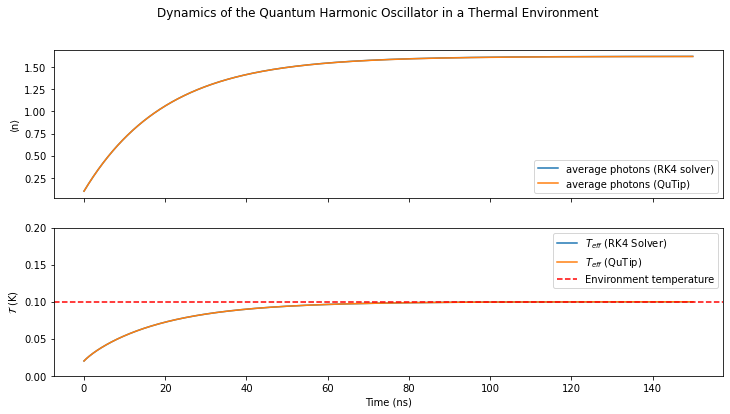

In [11]:
plot_eff_T(times, RK4_n_result, result.expect[0], T1_eff_t, T2_eff_t, Te)

The system gradually reaches equilibrium, as expected. At each plot, we see that the two solution curves overlap, so the RK4 solution is very accurate and close to QuTip results. 

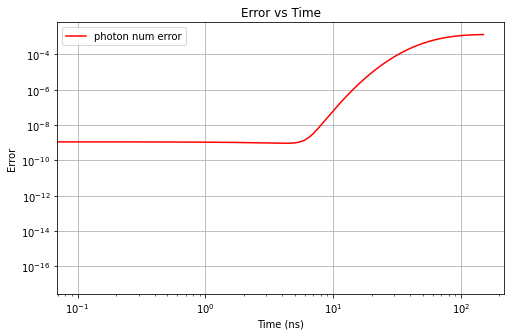

In [12]:
calculate_and_plot_error(RK4_n_result, result.expect[0], times, 'photon num error')

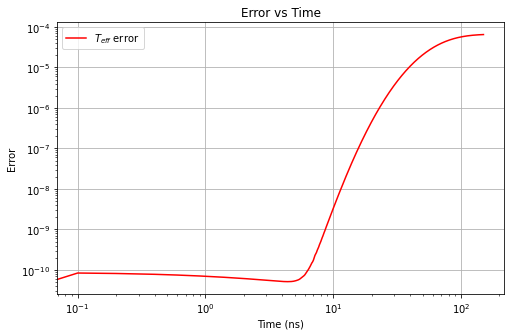

In [13]:
calculate_and_plot_error(T1_eff_t, T2_eff_t, times, '$T_{eff}$ error')

We find that the error increases sharply from time ~ 10 ns, and finally reaching around magnitude of $10^{-4}$. The error may come from the calculation of photon term $1/(\exp(\hbar\omega/kT)+1)$. At around 10ns, the photon number happens to reach half of the equilibrium photon numbers. The value of two terms $n_{T}$ and $n_{T_e}$ become much more close to each other. Calculating such inverse of exponential terms will cause highe order error when given slight different parameter inputs.  The magnitude is about square of $\exp(\hbar/kT)/(\exp(\hbar\omega/kT)+1)$. 

This error source effect will be shown in the following cases as well. However, due to more complicated frequency control, more error will be introduced from abrupt change of parameter. 

<a id="step"></a>
### Case B: Step-like modulation
In this case, we try to apply step-like modulation of frequency aiming to check how the physical quantities change under this jumping frequency. 

[(Back to top)](#table)

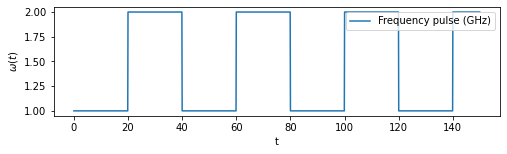

In [14]:
fig, axs = plt.subplots(figsize=(8, 2))

axs.plot(times, omega_t(times, args_step)/(2*np.pi), label='Frequency pulse (GHz)')
axs.set_xlabel('t')
axs.set_ylabel(r'$\omega(t)$')
axs.legend()

In [15]:
# Solve the ODE by RK4
start_time = time.time()
_, RK4_n_result = solve_Rk4(nth0, args_step, 0, tf, dt)
end_time = time.time()
print("Total run time:", end_time - start_time, "s")

Total run time: 0.11898326873779297 s


In [16]:
# Solve the Lindblad master equation
result = mesolve(H, psi0, times, c_ops, [a.dag() * a], args=args_step, progress_bar=True,\
                 options=Options(atol=1e-10, rtol=1e-8, store_states=True, nsteps=10000))

# Calculate the instantaneous effective temperature for each time point
T1_eff_t = hbar * omega_t(times, args_step) * 1e9 / (k * np.log(1 + 1 / result.expect[0]))
T2_eff_t = hbar * omega_t(times, args_step) * 1e9 / (k * np.log(1 + 1 / RK4_n_result))

10.0%. Run time:   0.09s. Est. time left: 00:00:00:00
20.0%. Run time:   0.19s. Est. time left: 00:00:00:00
30.0%. Run time:   0.28s. Est. time left: 00:00:00:00
40.0%. Run time:   0.40s. Est. time left: 00:00:00:00
50.0%. Run time:   0.46s. Est. time left: 00:00:00:00
60.0%. Run time:   0.57s. Est. time left: 00:00:00:00
70.0%. Run time:   0.67s. Est. time left: 00:00:00:00
80.0%. Run time:   0.75s. Est. time left: 00:00:00:00
90.0%. Run time:   0.89s. Est. time left: 00:00:00:00
Total run time:   0.97s


In this case, the increased running time of both method are likely from additional callings of step pulse function. However, the RK4 method is still 10 times faster. 

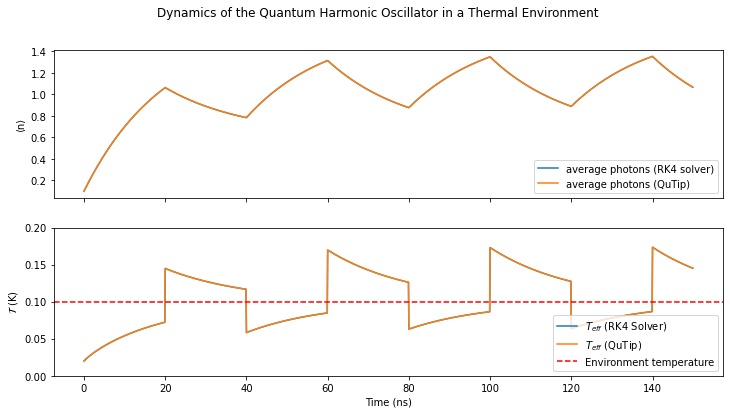

In [17]:
plot_eff_T(times, RK4_n_result, result.expect[0], T1_eff_t, T2_eff_t, Te)

The plotting overlap again as free damping case. This jumping frequency control drives the system out-of-equilibrium in periods and leads to asymmetrical temperature spectrum around bath temperature $T_e$. The tempreature jumps at when frequency suddenly shifts. The fast warming corresponds to sudden increasing frequency and fast cooling corresponds to sudden decreasing frequency. 

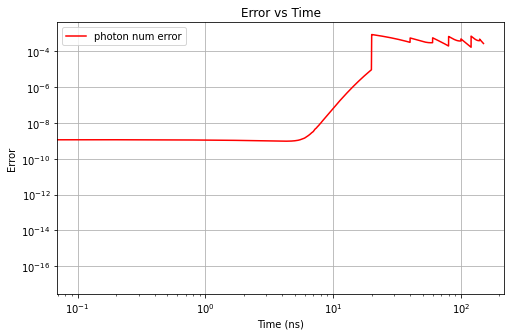

In [18]:
calculate_and_plot_error(RK4_n_result, result.expect[0], times, 'photon num error')

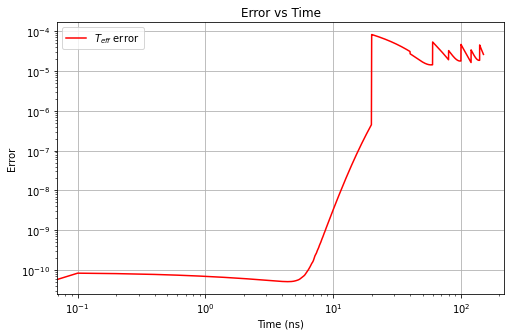

In [19]:
calculate_and_plot_error(T1_eff_t, T2_eff_t, times, '$T_{eff}$ error')

The error level is similar to damping case.

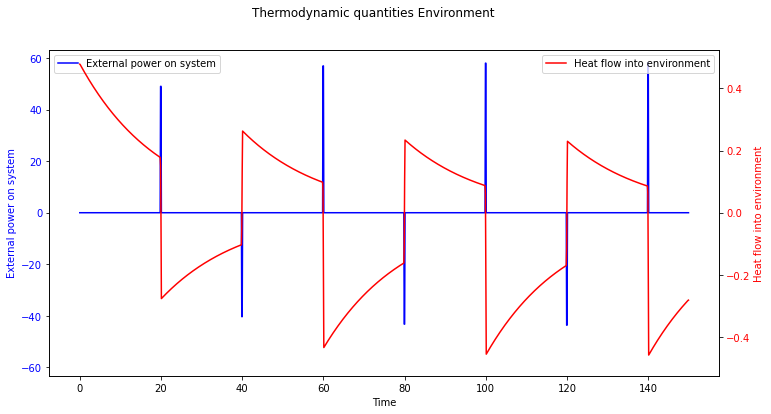

In [20]:
P1, J1 = calculate_power_and_heat_current(times, omega_t, RK4_n_result, args_step)
P2, J2 = calculate_power_and_heat_current(times, omega_t, result.expect[0], args_step)
plot_power_heat_current(times, P1, J1)

In case B and C, we only plot heat and power for one solver result to avoid messy plots. The results are quite close and error plots are plotted as below. 

This peak-like power phenomenon is not suprising as we jumped the frequency periodically. There certain amount of work done on the system during very short time (instanatly), but the heat current is continously going down showing that the heat is slowly transported to heat bath. The positive axis means heat current from heat bath and negative axis means heat current into bath. 

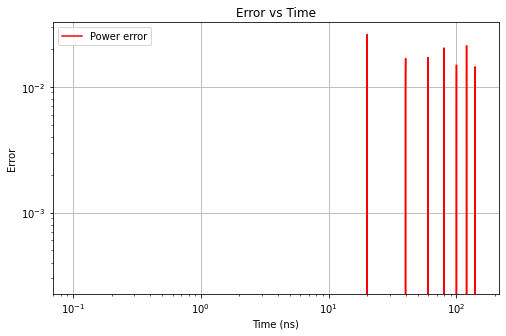

In [21]:
calculate_and_plot_error(P1, P2, times, 'Power error')

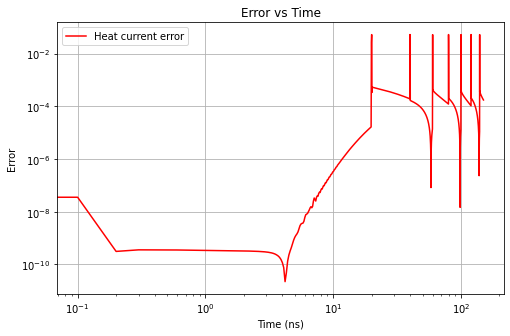

In [22]:
calculate_and_plot_error(J1, J2, times, 'Heat current error')

We did not plot both solver results of the power and heat current in the same case but only plotted one of them. It avoid messy plotting. Let us check only the error between two cases, and the errors are jumping as well. This expected for step-like control. 

<a id="sine"></a>
### Case C: Sine wave modulation

[(Back to top)](#table)

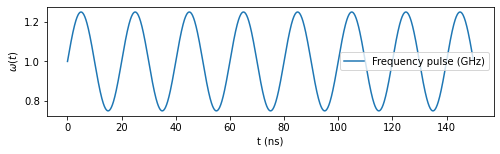

In [23]:
fig, axs = plt.subplots(figsize=(8, 2))

axs.plot(times, omega_t(times, args_sine)/(2*np.pi), label='Frequency pulse (GHz)')
axs.set_xlabel('t (ns)')
axs.set_ylabel(r'$\omega(t)$')
axs.legend()

In [24]:
# Solve the ODE by RK4
start_time = time.time()
_, RK4_n_result = solve_Rk4(nth0, args_sine, 0, tf, dt)
end_time = time.time()
print("Total run time:", end_time - start_time, "s")

Total run time: 0.13295722007751465 s


In [25]:
# Solve the Lindblad master equation
result = mesolve(H, psi0, times, c_ops, [a.dag() * a], args=args_sine, progress_bar=True, \
                 options=Options(atol=1e-10, rtol=1e-8, store_states=True, nsteps=10000))

# Calculate the instantaneous effective temperature for each time point
T1_eff_t = hbar * omega_t(times, args_sine) * 1e9 / (k * np.log(1 + 1 / result.expect[0]))
T2_eff_t = hbar * omega_t(times, args_sine) * 1e9 / (k * np.log(1 + 1 / RK4_n_result))

10.0%. Run time:   0.22s. Est. time left: 00:00:00:02
20.0%. Run time:   0.35s. Est. time left: 00:00:00:01
30.0%. Run time:   0.49s. Est. time left: 00:00:00:01
40.0%. Run time:   0.61s. Est. time left: 00:00:00:00
50.0%. Run time:   0.71s. Est. time left: 00:00:00:00
60.0%. Run time:   0.81s. Est. time left: 00:00:00:00
70.0%. Run time:   0.92s. Est. time left: 00:00:00:00
80.0%. Run time:   1.01s. Est. time left: 00:00:00:00
90.0%. Run time:   1.10s. Est. time left: 00:00:00:00
Total run time:   1.23s


In this case, the speed of RK4 solver still keeps around 10 times faster. 

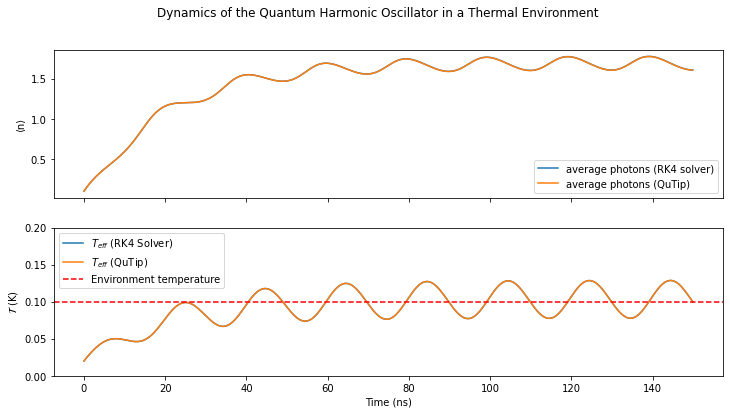

In [26]:
plot_eff_T(times, RK4_n_result, result.expect[0], T1_eff_t, T2_eff_t, Te)

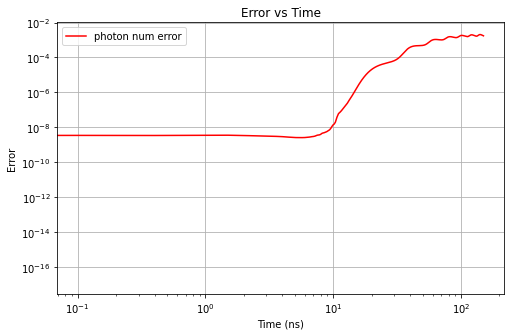

In [27]:
calculate_and_plot_error(RK4_n_result, result.expect[0], times, 'photon num error')

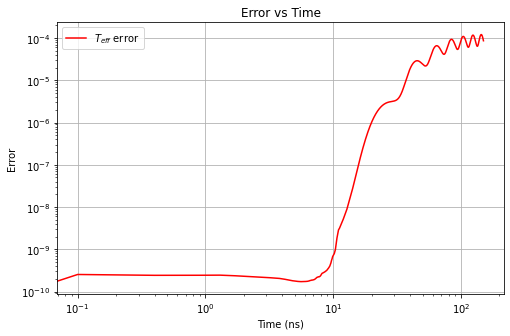

In [28]:
calculate_and_plot_error(T1_eff_t, T2_eff_t, times, '$T_{eff}$ error')

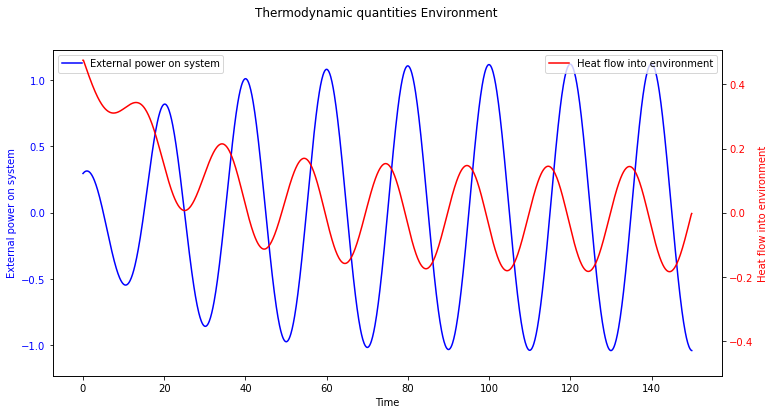

In [29]:
P1, J1 = calculate_power_and_heat_current(times, omega_t, RK4_n_result, args_sine)
P2, J2 = calculate_power_and_heat_current(times, omega_t, result.expect[0], args_sine)
plot_power_heat_current(times, P1, J1)

There are two stages of the evolution. First is the transient process, and then system will reach out-of-equilibrium steady state, in which the power absorbed by system and heat current into environment are both in sine wave function, but with phase difference. The heat current is delayed with a constant wave compared to power. In such out-of-equilibrium steady state, the total work and heat averages to be zero during a full period of time. 

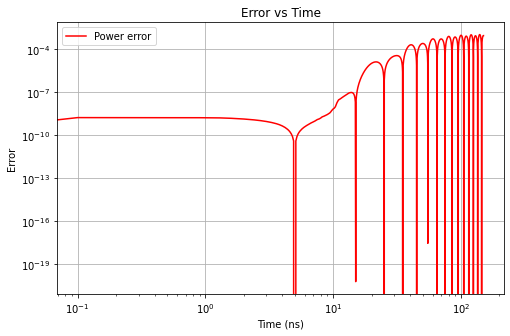

In [30]:
calculate_and_plot_error(P1, P2, times, 'Power error')

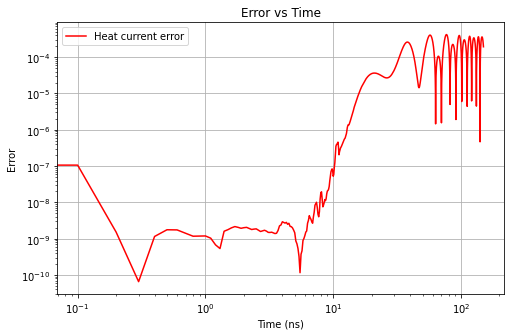

In [31]:
calculate_and_plot_error(J1, J2, times, 'Heat current error')

In sine wave modulation, which is smooth function control, the error level of P, J is similar to the level of effective tempreature. 

## 5. Summary

We compared our RK4 solver results with qutip solver results, and find that they fit quite well with each other. Under smooth frequency control, the typical error is order $10^{-4}$ for long time dynamics near equilibrium, which is neligible for most scientific calculation needs. Worse cases for some quantites may have error of order $10^{-2}$. In short, the pure quantum method by solving quantum optical master equation is equivalent to the obtained ODE by Gaussian techniques. 

The time efficiency is compared by calculating exact time cost for calculation. The real time cost are involved with many possible sources, expecially for QuTip cases. The backend acceleration method of qutip implementation matters. Generally, we have shown the numerical efficiency advantage of Gaussian technique ODE over the quantum master equation. 

We analyzed three cases of different dynamics using typical experimental parameters. The free damping cases are usual textbook example and simulation results are not surprising. The step-like control of frequency shows interesting jump for work done on system and relatively slow heat current response. Lastly, the monochromatic frequency control shows very beautiful in- and out-of phase work and heat coherence. 

[(Back to top)](#table)
<a id="ref"></a>

## Reference 

[1] P. Portugal, F. Brange, and C. Flindt, Effective Temperature Pulses in Open Quantum Systems, Physical Review Research 4, 043112 (2022).

[2] Crispin Gardiner and Peter Zoller. Quantum noise: a handbook of Markovian and non-Markovian quantum stochastic methods with applications to quantum optics. Springer Science & Business Media (2004).

[3] M. O. Scully and M. S. Zubairy, Quantum Optics (1997).

[4] A. Seegebrecht and T. Schilling, Work, Heat and Internal Energy in Open Quantum Systems: A Comparison of Four Approaches from the Autonomous System Framework, https://arxiv.org/abs/2308.08215.

[5] J. R. Johansson, P. D. Nation, and F. Nori, QuTiP 2: A Python Framework for the Dynamics of Open Quantum Systems, Computer Physics Communications 184, 1234 (2013).


[(Back to top)](#table)